# 01 - Drag Buildup

`evtolpy` uses a **component drag buildup** method to compute the total cruise drag coefficient. This is the standard approach in conceptual aircraft design (Raymer, Roskam). Each airframe component contributes a parasitic drag term ($C_{D0}$), and induced drag is computed from the cruise coefficient of lift.

The total cruise drag coefficient is:

$$C_D = \left(C_{D0,fuse} + C_{D0,wing} + C_{D_i} + C_{D0,HT} + C_{D0,VT} + C_{D0,gear} + C_{D0,rotor}\right) \times K_{trim} \times K_{excres}$$

where:
- **Parasite drag** ($C_{D0}$) comes from skin friction and pressure drag on each component, referenced to wing area
- **Induced drag** ($C_{D_i}$) arises from lift generation: $C_{D_i} = \frac{C_L^2}{\pi \cdot AR \cdot e}$
- **Trim drag factor** ($K_{trim}$) accounts for drag from control surface deflections
- **Excrescence factor** ($K_{excres}$) accounts for misc drag components (antennas, gaps, etc.)

The cruise L/D ratio ($L/D = C_L / C_D$) is very important for eVTOL sizing since cruise dominates the total mission energy.

In [6]:
import sys
sys.path.append('../../evtol')
from aircraft import Aircraft

aircraft = Aircraft('../Archer_Midnight.json')

## Fuselage Drag

The fuselage drag is estimated using **Hoerner's equations**, an empirical method for streamlined bodies:

1. **Fineness ratio** ($l/d$) from fuselage length and equivalent diameter where higher ratios mean more slender shapes with lower form drag
2. **Form factor** ($C_{D0}/C_f$) from Hoerner Eq. 6.31 which converts flat plate friction to 3D body drag
3. **Skin friction coefficient** ($C_f$) from Prandtl-Schlichting that depends on Reynolds number
4. **Fuselage $C_{D0}$** = form factor × $C_f$ × $S_{wet,fuse} / S_{wing}$ which is referenced to wing planform area

It should be noted that fuselage drag is dominated by **form drag**.

In [7]:
print("Fuselage Drag Estimation")
print(f"  Fineness Ratio:         {aircraft.fuselage_fineness_ratio:.3f}")
print(f"  CD0/Cf (form factor):   {aircraft.fuselage_cd0_p_cf:.3f}")
print(f"  Cruise Reynolds Number: {aircraft.fuselage_cruise_reynolds:.0f}")
print(f"  Skin Friction Cf:       {aircraft.fuselage_cf:.6f}")
print(f"  Fuselage CD0:           {aircraft.fuselage_cd0:.6f}")

Fuselage Drag Estimation
  Fineness Ratio:         5.625
  CD0/Cf (form factor):   19.436
  Cruise Reynolds Number: 40166640
  Skin Friction Cf:       0.002426
  Fuselage CD0:           0.004475


## Component Drag Breakdown

Each component's $C_{D0}$ is computed independently and referenced to the wing planform area. For cruise, two additional terms appear:

- **Wing airfoil $C_D$**: profile drag of the wing
- **Stopped rotor $C_{D0}$**: drag from stopped lift rotors (unique to eVTOLs with dedicated cruise rotors)

The induced drag coefficient is: $C_{D_i} = C_L^2 / (\pi \cdot AR \cdot e)$, where $e$ is the Oswald span efficiency factor.

In [8]:
drag_components = {
    'Fuselage CD0':       aircraft.fuselage_cd0,
    'Wing Airfoil CD':    aircraft.wing_airfoil_cd_at_cruise_cl,
    'Induced Drag CDi':   aircraft.induced_drag_cdi,
    'Horiz Tail CD0':     aircraft.horiz_tail_cd0,
    'Vert Tail CD0':      aircraft.vert_tail_cd0,
    'Landing Gear CD0':   aircraft.landing_gear_cd0,
    'Stopped Rotor CD0':  aircraft.stopped_rotor_cd0,
}

total_before_factors = sum(drag_components.values())

print(f"{'Component':<25s} {'CD':>12s} {'% of Total':>10s}")
print("-" * 50)
for name, cd in drag_components.items():
    pct = 100 * cd / total_before_factors
    print(f"{name:<25s} {cd:>12.6f} {pct:>9.1f}%")
print("-" * 50)
print(f"{'Sum (before factors)':<25s} {total_before_factors:>12.6f}")
print(f"")
print(f"Trim Drag Factor:      {aircraft.trim_drag_factor}")
print(f"Excres/Protub Factor:  {aircraft.excres_protub_factor}")
print(f"")
print(f"Total Cruise CD:       {aircraft.cruise_cd:.6f}")

Component                           CD % of Total
--------------------------------------------------
Fuselage CD0                  0.004475       9.6%
Wing Airfoil CD               0.006500      14.0%
Induced Drag CDi              0.010410      22.4%
Horiz Tail CD0                0.002295       4.9%
Vert Tail CD0                 0.001693       3.6%
Landing Gear CD0              0.003304       7.1%
Stopped Rotor CD0             0.017792      38.3%
--------------------------------------------------
Sum (before factors)          0.046470

Trim Drag Factor:      1.05
Excres/Protub Factor:  1.03

Total Cruise CD:       0.050257


## Cruise Lift-to-Drag Ratio

The cruise L/D is the ratio of lift coefficient to total drag coefficient. For steady, level cruise, lift equals weight:

$$L = W = mg \quad \Rightarrow \quad C_L = \frac{mg}{q \cdot S_{wing}} = \frac{2mg}{\rho V^2 S_{wing}}$$

The cruise L/D directly determines cruise power: $P_{cruise} = \frac{D \cdot V}{\eta_{rotor}} = \frac{mg \cdot V}{\eta_{rotor} \cdot (L/D)}$

Higher L/D means less cruise power and less energy for the longest mission segment.

In [9]:
print(f"Cruise CL:  {aircraft.cruise_cl:.4f}")
print(f"Cruise CD:  {aircraft.cruise_cd:.6f}")
print(f"Cruise L/D: {aircraft.cruise_l_p_d:.2f}")

Cruise CL:  0.5355
Cruise CD:  0.050257
Cruise L/D: 10.66


## Drag Breakdown Visualization

The bar chart shows each component's contribution. In a typical eVTOL configuration:
- **Stopped rotor drag** is a penalty specific to designs with dedicated lift rotors
- **Landing gear** drag can be significant if gear is not retractable

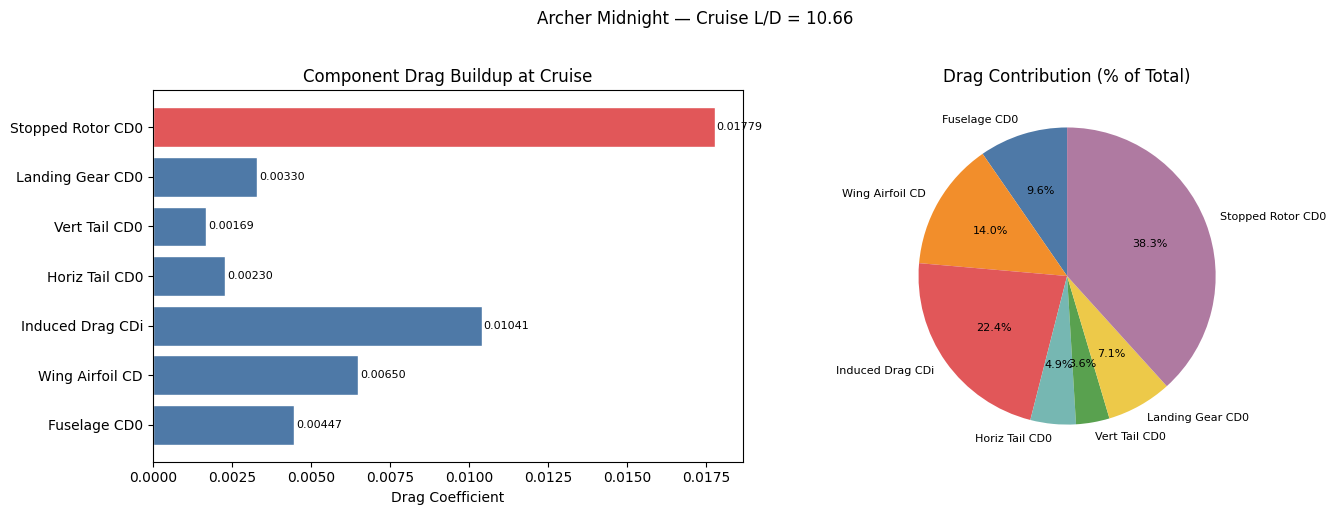

In [ ]:
import matplotlib.pyplot as plt

names = list(drag_components.keys())
values = list(drag_components.values())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Horizontal bar chart
colors_bar = ['#e15759' if v == max(values) else '#4e79a7' for v in values]
bars = ax1.barh(names, values, color=colors_bar, edgecolor='white')
ax1.set_xlabel('Drag Coefficient')
ax1.set_title('Component Drag Buildup at Cruise')
for bar, val in zip(bars, values):
    ax1.text(bar.get_width() + 0.00005, bar.get_y() + bar.get_height()/2,
            f'{val:.5f}', va='center', fontsize=8)

# Pie chart showing relative contributions
colors_pie = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f', '#edc949', '#af7aa1']
wedges, texts, autotexts = ax2.pie(values, labels=names, autopct='%1.1f%%',
                                     colors=colors_pie[:len(values)], startangle=90,
                                     textprops={'fontsize': 8})
ax2.set_title('Drag Contribution (% of Total)')

plt.suptitle(f'Archer Midnight Cruise L/D = {aircraft.cruise_l_p_d:.2f}', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## Summary

Key aerodynamic insights for the Archer Midnight:

- **Component drag buildup** is the standard conceptual design approach, each component contributes independently, then correction factors are applied
- **Fuselage drag** uses Hoerner's empirical equations, the fineness ratio and Reynolds number determine skin friction and form factor
- **Induced drag** ($C_{D_i} = C_L^2 / (\pi \cdot AR \cdot e)$) depends on the cruise lift coefficient, wing aspect ratio, and span efficiency where a higher AR directly reduces induced drag
- **Stopped rotor drag** is a penalty for dedicated lift rotor configurations where idle lift rotors add drag during wing borne flight
- **Trim and excrescence factors** apply correction factors to the sum of all components
- **Cruise L/D** directly determines cruise shaft power via $P = mgV / (\eta \cdot L/D)$

**Next:** Move on to [07 - Propulsion and Battery] to explore the rotor and battery models.